In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

In [2]:
df_org=pd.read_csv('Telco_churn_dataset.csv')

In [3]:
df_org.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4598,4929-ROART,Male,0,No,No,18,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,56.25,969.85,No
2619,3336-JORSO,Female,1,No,No,33,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,110.45,3655.45,Yes
3865,5701-SVCWR,Female,0,No,Yes,1,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,24.00,24,No
4444,0137-UDEUO,Female,0,No,No,3,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.85,63.75,Yes


In [4]:
X = df_org.drop('Churn', axis=1)
Y = df_org['Churn']

In [5]:
Y = Y.map({
    'Yes':1,
    'No':0
})
Y = Y.astype(int)

In [6]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer)


# Evaluation Metrics
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)




num_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

multi_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

binary_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
]


def basic_cleaning(df1):

    df1 = df1.copy()

    # Remove customerID
    df1 = df1.drop('customerID', axis=1)

    # Convert TotalCharges
    df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],errors='coerce')

    # Fill missing values
    df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())

    # Binary mapping
    binary_map = {
        'Yes':1,
        'No':0,
        'Female':0,
        'Male':1
    }

    for col in binary_columns:
        df1[col] = df1[col].map(binary_map)

    return df1

In [9]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_columns ),
                                  ('cat', OneHotEncoder(drop='first'),multi_columns)
                                  ],remainder='passthrough')

In [12]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    pipe = Pipeline([
            ('cleaning', FunctionTransformer(basic_cleaning)),
            ('preprocessing', preprocessor),('kmeans',kmeans)
        ])

    pipe.fit(X_train)

    wcss.append(kmeans.inertia_)
     

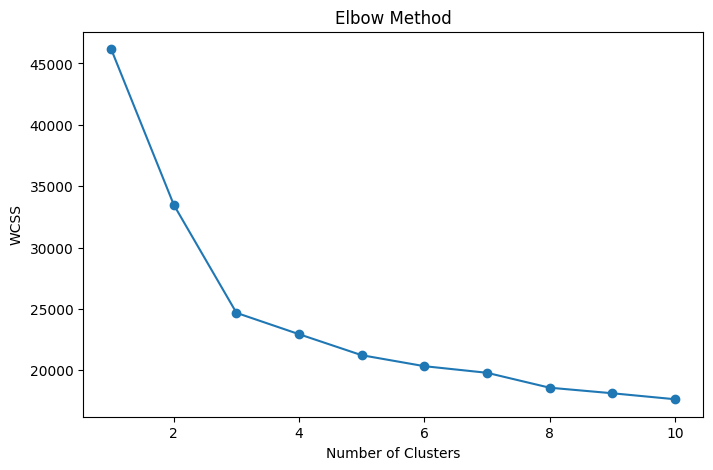

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [17]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

pipe = Pipeline([
            ('cleaning', FunctionTransformer(basic_cleaning)),
            ('preprocessing', preprocessor),('kmeans',kmeans)
        ])
clusters = pipe.fit_predict(X_train)
     
